# **Tehran weather condition in new year**

#### **1: Problem Definition**

In this project, we will analyze historical weather data to predict temperature and rainfall patterns in 2025.

#### **2: Import libraries and datas**

In [ ]:
# prompt: import data analysis require libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

# from sklearn.decomposition import PCA


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/dataset/Tehran, Iran yeartodate.csv'

df=pd.read_csv(file_path)
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,"Tehran, Iran",2025-01-01,7.1,1.7,4.2,4.0,-1.4,1.6,-2.6,61.9,...,9.6,5,10,2025-01-01T07:14:18,2025-01-01T17:01:51,0.05,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"OIIE,OIIP,40754099999,40780799999,40730099999,..."
1,"Tehran, Iran",2025-01-02,8.1,-0.1,3.7,6.1,-3.8,0.9,-6.8,48.9,...,11.5,6,10,2025-01-02T07:14:28,2025-01-02T17:02:38,0.09,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"OIIE,OIIP,40754099999,40780799999,40730099999,..."
2,"Tehran, Iran",2025-01-03,8.3,-1.1,4.1,6.4,-1.9,2.5,-8.7,40.6,...,11.7,6,10,2025-01-03T07:14:35,2025-01-03T17:03:26,0.12,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"OIIE,OIIP,40754099999,40780799999,40730099999,..."
3,"Tehran, Iran",2025-01-04,10.1,-0.3,4.7,10.1,-2.3,3.4,-8.7,39.3,...,12.1,6,10,2025-01-04T07:14:41,2025-01-04T17:04:16,0.16,Clear,Clear conditions throughout the day.,clear-day,"OIIE,OIIP,40754099999,40780799999,40730099999,..."
4,"Tehran, Iran",2025-01-05,11.3,0.8,5.8,11.3,-1.8,5.0,-9.5,34.6,...,12.1,6,10,2025-01-05T07:14:45,2025-01-05T17:05:06,0.19,Clear,Clear conditions throughout the day.,clear-day,"OIIE,OIIP,40754099999,40780799999,40730099999,..."


#### **3: Data Cleaning & Preprocessing**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              115 non-null    object 
 1   datetime          115 non-null    object 
 2   tempmax           115 non-null    float64
 3   tempmin           115 non-null    float64
 4   temp              115 non-null    float64
 5   feelslikemax      115 non-null    float64
 6   feelslikemin      115 non-null    float64
 7   feelslike         115 non-null    float64
 8   dew               115 non-null    float64
 9   humidity          115 non-null    float64
 10  precip            115 non-null    float64
 11  precipprob        115 non-null    float64
 12  precipcover       115 non-null    float64
 13  preciptype        47 non-null     object 
 14  snow              115 non-null    float64
 15  snowdepth         115 non-null    float64
 16  windgust          115 non-null    float64
 1

In [ ]:
df['datetime']=pd.to_datetime(df['datetime'])
df.dtypes['datetime']

dtype('<M8[ns]')

This project focuses on temperature prediction, requiring only a limited dataset for analysis.

In [ ]:
relevant_cols = ['datetime', 'temp','tempmax','tempmin', 'humidity', 'windspeed', 'precip']
df_temp = df[relevant_cols].copy()

df_temp.dropna(subset=['temp'], inplace=True)

df_temp.shape


(115, 7)

#### **4: Recognizing and managing outlier temperatures**

In [ ]:
def show_range(x):
    Q1 = np.percentile(x, 25)
    Q3 = np.percentile(x, 75)
    IQR = Q3 - Q1
    low_range = Q1 - 1.5 * IQR
    top_range = Q3 + 1.5 * IQR

    return low_range, top_range


low_range_temp, top_range_temp = show_range(df_temp["temp"])

temp_outliers = np.where((df_temp["temp"] < low_range_temp) & (df_temp["temp"] > top_range_temp))

df_temp.drop(df_temp.iloc[temp_outliers].index, inplace=True)

df_temp.head()



,datetime,temp,tempmax,tempmin,humidity,windspeed,precip
0,2025-01-01,4.2,7.1,1.7,61.9,22.0,0.0
1,2025-01-02,3.7,8.1,-0.1,48.9,17.7,0.0
2,2025-01-03,4.1,8.3,-1.1,40.6,18.2,0.0
3,2025-01-04,4.7,10.1,-0.3,39.3,18.8,0.0
4,2025-01-05,5.8,11.3,0.8,34.6,14.3,0.0


#### **5: EDA - Exploratory Data Analysis**

##### **Descriptive statistics**

In [ ]:
df_temp.describe()

,datetime,temp,tempmax,tempmin,humidity,windspeed,precip
count,115,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,2025-02-27 00:00:00,10.791304,15.009565,6.248696,37.638261,24.387826,0.493043
min,2025-01-01 00:00:00,-2.100000,2.000000,-6.900000,14.800000,10.900000,0.000000
25%,2025-01-29 12:00:00,4.900000,8.900000,1.650000,24.450000,16.950000,0.000000
50%,2025-02-27 00:00:00,8.400000,13.000000,4.700000,34.600000,21.700000,0.000000
75%,2025-03-27 12:00:00,16.650000,21.100000,11.750000,47.500000,30.400000,0.000000
max,2025-04-25 00:00:00,25.000000,29.100000,19.600000,75.400000,61.500000,9.200000
std,NaN,6.978420,7.223208,6.598091,15.963597,10.282263,1.574842


##### **Visiolation**

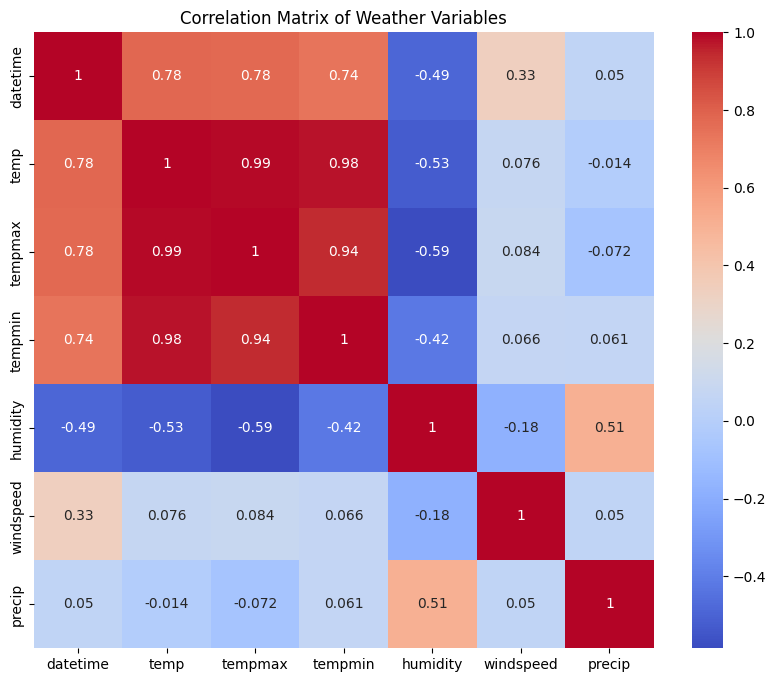

In [ ]:

# Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_temp.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Weather Variables')
plt.show()


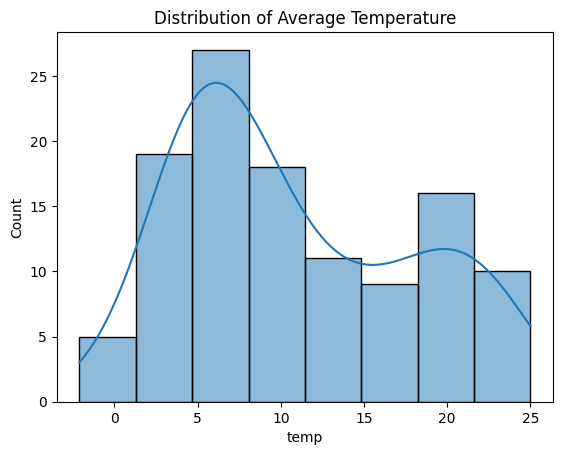

In [ ]:

sns.histplot(df_temp['temp'], kde=True)
plt.title('Distribution of Average Temperature')
plt.show()


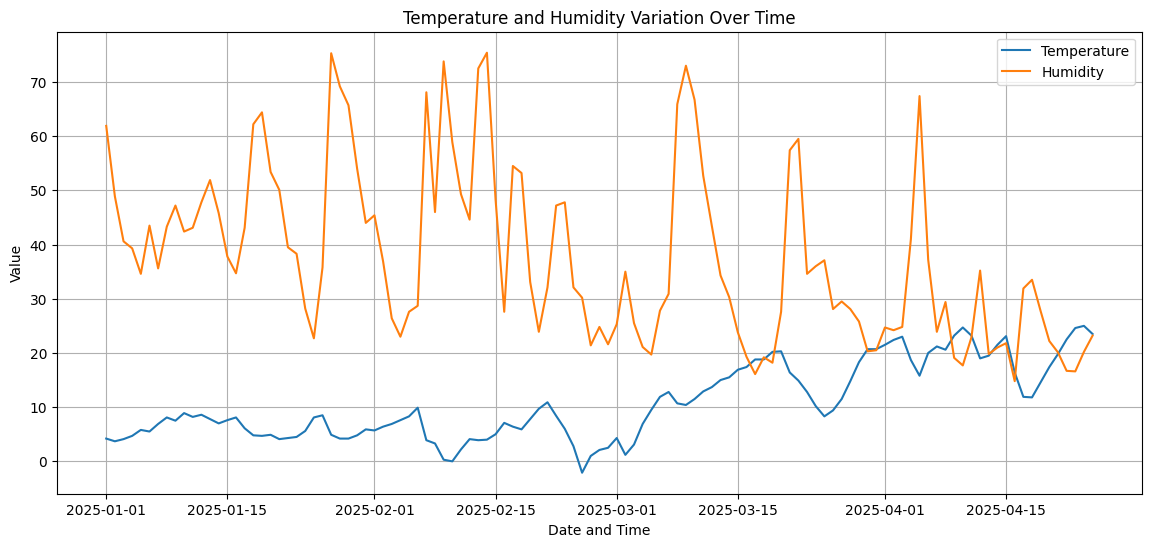

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df_temp['datetime'], df_temp['temp'], label='Temperature')
plt.plot(df_temp['datetime'], df_temp['humidity'], label='Humidity')
plt.xlabel('Date and Time')
plt.ylabel('Value')
plt.title('Temperature and Humidity Variation Over Time')
plt.grid(True)
plt.legend()
plt.show()



##### **Analyze monthly temperature patterns**

<ipython-input-48-98ab17e956d9>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean_temp = df.groupby(pd.Grouper(key='datetime', freq='M'))['temp'].mean()


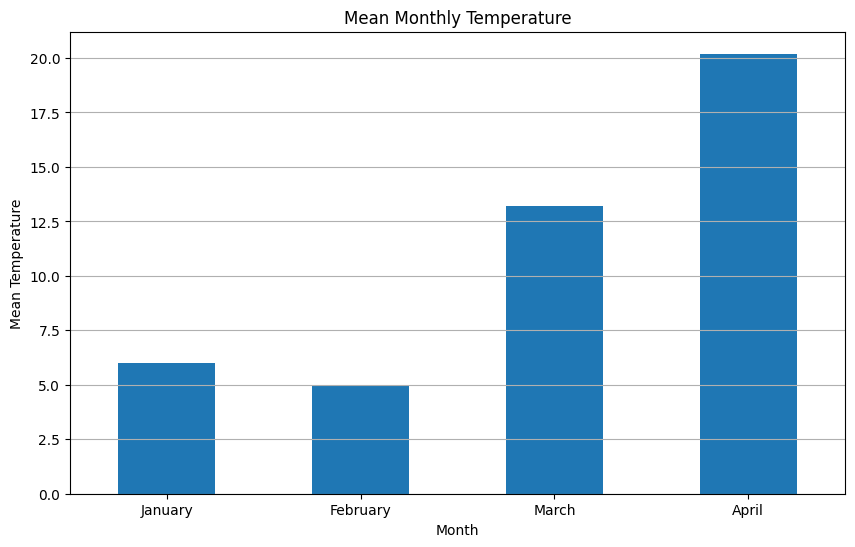

In [ ]:

monthly_mean_temp = df.groupby(pd.Grouper(key='datetime', freq='M'))['temp'].mean()

# dfemp.info()

monthly_mean_temp.index = monthly_mean_temp.index.strftime('%B')


# Create a bar plot
plt.figure(figsize=(10, 6))
monthly_mean_temp.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Mean Temperature')
plt.title('Mean Monthly Temperature')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.grid(axis='y')
plt.show()


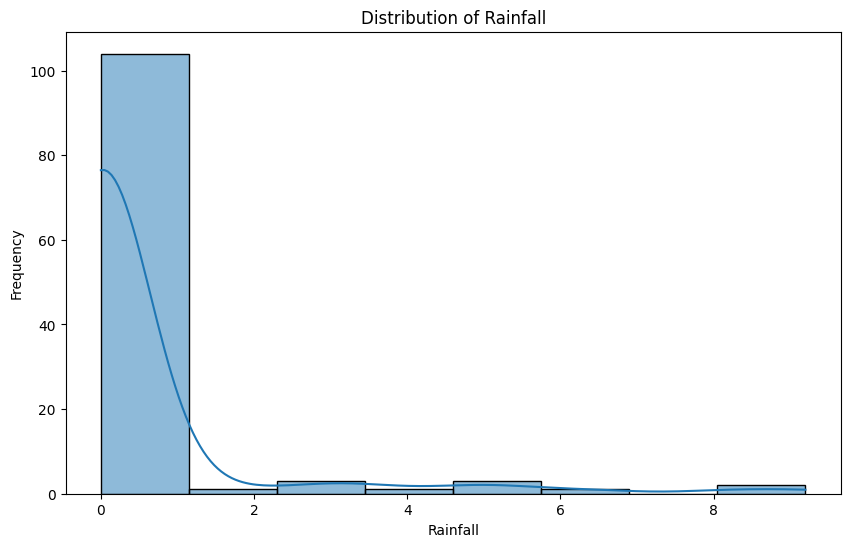

In [ ]:

plt.figure(figsize=(10, 6))
sns.histplot(df_temp['precip'], kde=True)
plt.xlabel('Rainfall')
plt.ylabel('Frequency')
plt.title('Distribution of Rainfall')
plt.show()



<ipython-input-50-7dd130791553>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean_humidity = df.groupby(pd.Grouper(key='datetime', freq='M'))['humidity'].mean()


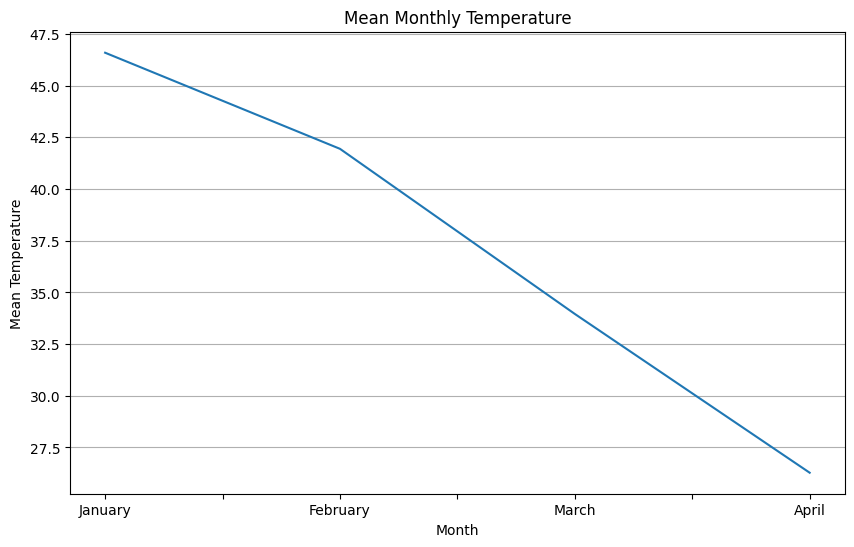

In [ ]:
monthly_mean_humidity = df.groupby(pd.Grouper(key='datetime', freq='M'))['humidity'].mean()

# dfemp.info()

monthly_mean_humidity.index = monthly_mean_humidity.index.strftime('%B')


# Create a bar plot
plt.figure(figsize=(10, 6))
monthly_mean_humidity.plot()
plt.xlabel('Month')
plt.ylabel('Mean Temperature')
plt.title('Mean Monthly Temperature')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

##### **Time trend is characteristic.**

Temperature change process

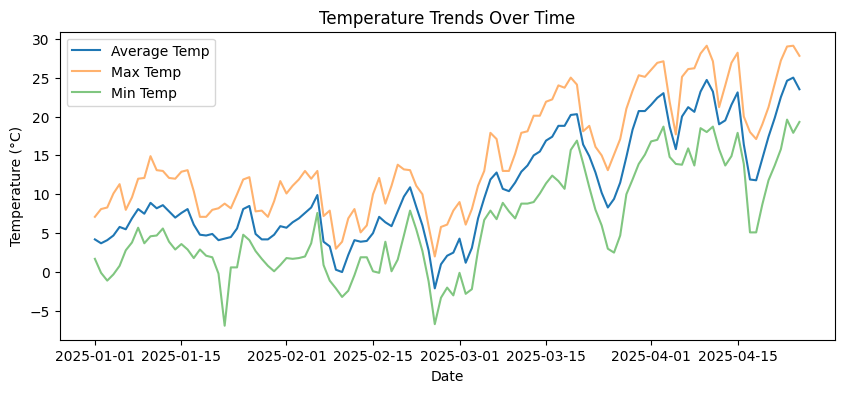

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df_temp['datetime'], df_temp['temp'], label='Average Temp')
plt.plot(df_temp['datetime'], df_temp['tempmax'], label='Max Temp', alpha=0.6)
plt.plot(df_temp['datetime'], df_temp['tempmin'], label='Min Temp', alpha=0.6)
plt.legend()
plt.title('Temperature Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

Humidity and precipitation trends

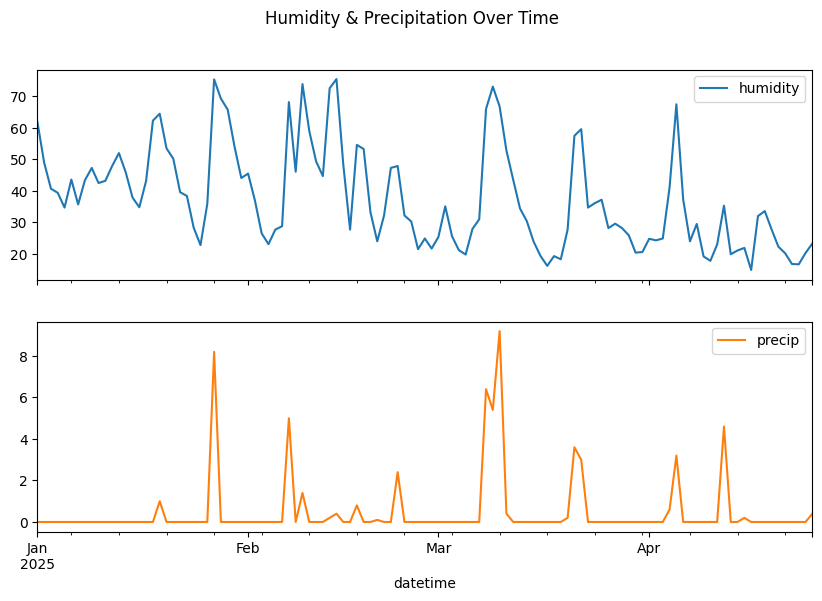

In [ ]:
df_temp.set_index('datetime')[['humidity', 'precip']].plot(subplots=True, figsize=(10,6), title='Humidity & Precipitation Over Time')
plt.show()

In [ ]:
correlation_columns = ['tempmax','tempmin','humidity','windspeed','precip']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_temp.loc[:,correlation_columns], df_temp['temp'].values, random_state=0)